# W7-X Neutronics Showcase

<div align="center">
  <img src="../../_static/w7x_mesh.png" alt="Basalt-generated tetrahedral mesh of the public W7-X stellarator fixture" width="80%" />
  <p><em>Basalt-generated tetrahedral mesh of the public Wendelstein 7-X stellarator fixture (plasma vessel and planar coils) — the artifact this notebook builds. See the <a href="https://basalt-mesh.readthedocs.io/en/latest/notebooks/tutorials/w7x_neutronics.html">W7-X neutronics tutorial</a> rendered on Read the Docs.</em></p>
</div>


End-to-end demonstration of basalt's role in a fusion neutronics workflow. We take the Proxima Fusion W7-X stellarator fixture (Parasolid input), produce a tetrahedral mesh annotated for DAGMC, convert it through stellarmesh, then run an OpenMC fixed-source DT-neutron calculation against four tallies.

**Prerequisites:**

- a working basalt install (requires a Simmetrix SimModSuite license and the corresponding module tarballs — see [install](../../install.rst))
- the W7-X fixture at `tests/data/scaled_w7x_stellarator.x_t` (LFS-tracked, MIT)

> **Note — fixture scale.** The Proxima `open_stellarator_models` fixture has a known upstream scale-loss bug ([proximafusion/open_stellarator_models#4](https://github.com/proximafusion/open_stellarator_models/issues/4)): the model was authored as a power-plant-scale stellarator (~34 m extent) but exported with numeric values 1000× smaller. We compensate by passing `scale_factor=1e5` at gmsh-export time.

In [ ]:
import logging
import os
import tempfile
from pathlib import Path

import numpy as np
import openmc
import openmc.stats
import pyvista as pv
import stellarmesh as sm
from IPython.display import Image, display

import basalt as bslt

# Fail fast if OpenMC has no cross-section data configured. The notebook's
# `openmc.run()` step would otherwise fail 20+ minutes in after the meshing
# pipeline is done. Set OPENMC_CROSS_SECTIONS to a cross_sections.xml path
# (e.g. ENDF/B-VIII.0) before running. See:
# https://docs.openmc.org/en/stable/usersguide/cross_sections.html
if not os.environ.get("OPENMC_CROSS_SECTIONS"):
    raise RuntimeError(
        "OPENMC_CROSS_SECTIONS is not set. Point it at a cross_sections.xml "
        "(e.g. ENDF/B-VIII.0) before running this notebook."
    )

logging.basicConfig()
for name in ("basalt", "stellarmesh"):
    logging.getLogger(name).setLevel(logging.INFO)

pv.set_jupyter_backend("static")

tmpdir = Path(tempfile.mkdtemp(prefix="w7x_neutronics_"))
print(f"Scratch directory: {tmpdir}")

Scratch directory: /tmp/w7x_neutronics_4n3dw1z4


/home/alex/Programming/phnx/.claude/worktrees/d-resume/.pixi/envs/default/lib/python3.12/site-packages/pymoab/__init__.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Stage 1 — Load the W7-X assembly

basalt reads the Parasolid (`.x_t`) export of the W7-X model along with its NX-attribute sidecar JSON. The sidecar carries the body centroids and `DB_PART_NAME` attributes that basalt uses to populate `material=` slugs in the output mesh — see the [format reference](../../format.rst) for the resolution rules.


In [2]:
fixture = Path("../../../tests/data/scaled_w7x_stellarator.x_t").resolve()
assert fixture.exists(), f"Fixture not found: {fixture}"

model = bslt.Model.from_parasolid_file(str(fixture), load_nx_attrs=True)
bslt.print_hierarchy(model)

[debug] Loading Parasolid file.
Assembly: <unnamed>
  Assembly: plasma_step
    Part: <unnamed>
      Region: <unnamed>
  Assembly: gap_step
    Part: <unnamed>
      Region: <unnamed>
  Assembly: coils
    Assembly: coil_0_step
      Part: <unnamed>
        Region: <unnamed>
    Assembly: coil_1_step
      Part: <unnamed>
        Region: <unnamed>
    Assembly: coil_2_step
      Part: <unnamed>
        Region: <unnamed>
    Assembly: coil_3_step
      Part: <unnamed>
        Region: <unnamed>
    Assembly: coil_4_step
      Part: <unnamed>
        Region: <unnamed>
    Assembly: coil_5_step
      Part: <unnamed>
        Region: <unnamed>
    Assembly: coil_6_step
      Part: <unnamed>
        Region: <unnamed>
    Assembly: coil_7_step
      Part: <unnamed>
        Region: <unnamed>
    Assembly: coil_8_step
      Part: <unnamed>
        Region: <unnamed>
    Assembly: coil_9_step
      Part: <unnamed>
        Region: <unnamed>
    Assembly: coil_10_step
      Part: <unnamed>
        

 (0.008, 0.012, -0.001) to component 'COIL_7' (dist=0.0000)
[debug] Matched part at (0.007, 0.013, -0.000) to component 'COIL_8' (dist=0.0000)
[debug] Matched part at (0.005, 0.014, -0.000) to component 'COIL_9' (dist=0.0000)
[debug] Matched part at (0.004, 0.014, 0.000) to component 'COIL_10' (dist=0.0000)
[debug] Matched part at (0.002, 0.014, 0.000) to component 'COIL_11' (dist=0.0000)
[debug] Matched part at (0.000, 0.014, 0.001) to component 'COIL_12' (dist=0.0000)
[debug] Matched part at (-0.001, 0.014, 0.000) to component 'COIL_13' (dist=0.0000)
[debug] Matched part at (-0.003, 0.013, 0.000) to component 'COIL_14' (dist=0.0000)
[debug] Matched part at (-0.005, 0.012, -0.000) to component 'COIL_15' (dist=0.0000)
[debug] Matched part at (-0.007, 0.012, -0.000) to component 'COIL_16' (dist=0.0000)
[debug] Matched part at (-0.009, 0.011, -0.001) to component 'COIL_17' (dist=0.0000)
[debug] Matched part at (-0.010, 0.010, -0.000) to component 'COIL_18' (dist=0.0000)
[debug] Matched p

## Stage 2 — Imprint and mesh

`make_non_manifold_model` performs the boolean imprint and merge so adjacent volumes share faces — required for a conformal mesh.

In [3]:
nm_model = model.make_non_manifold_model()

mesh_case = bslt.MeshCase(nm_model)
mesh_case.set_size(1.5e-2)  # global edge-length cap, fixture-native units

surface_mesh = bslt.SurfaceMesh.from_model(nm_model, mesh_case)
volume_mesh = bslt.VolumeMesh.from_surface_mesh(surface_mesh)
print("Meshing complete.")

[debug] Creating Non-Manifold Model.


[info] tag = 1, type = NURB
[info] tag = 2, type = NURB
[info] tag = 3, type = NURB
[info] tag = 4, type = NURB
[info] tag = 5, type = NURB
[info] tag = 6, type = NURB
[info] tag = 7, type = NURB
[info] tag = 8, type = NURB
[info] tag = 9, type = NURB
[info] tag = 10, type = NURB
[info] tag = 11, type = NURB
[info] tag = 12, type = NURB
[info] tag = 13, type = NURB
[info] tag = 14, type = NURB
[info] tag = 15, type = NURB
[info] tag = 16, type = NURB
[info] tag = 17, type = NURB
[info] tag = 18, type = NURB
[info] tag = 19, type = NURB
[info] tag = 20, type = NURB
[info] tag = 21, type = NURB
[info] tag = 22, type = NURB
[info] tag = 23, type = NURB
[info] tag = 24, type = NURB
[info] tag = 25, type = NURB
[info] tag = 26, type = NURB
[info] tag = 27, type = NURB
[info] tag = 28, type = NURB
[info] tag = 29, type = NURB
[info] tag = 30, type = NURB
[info] tag = 31, type = NURB
[info] tag = 32, type = NURB
[info] tag = 33, type = NURB
[info] tag = 34, type = NURB
[info] tag = 35, type =

B
[info] tag = 138, type = NURB
[info] tag = 139, type = NURB
[info] tag = 140, type = NURB
[info] tag = 141, type = NURB
[info] tag = 142, type = NURB
[info] tag = 143, type = NURB
[info] tag = 144, type = NURB
[info] tag = 145, type = NURB
[info] tag = 146, type = NURB
[info] tag = 147, type = NURB
[info] tag = 148, type = NURB
[info] tag = 149, type = NURB
[info] tag = 150, type = NURB
[info] tag = 151, type = NURB
[info] tag = 152, type = NURB
[info] tag = 153, type = NURB
[info] tag = 154, type = NURB
[info] tag = 155, type = NURB
[info] tag = 156, type = NURB
[info] tag = 157, type = NURB
[info] tag = 158, type = NURB
[info] tag = 159, type = NURB
[info] tag = 160, type = NURB
[info] tag = 161, type = NURB
[info] tag = 162, type = NURB
[info] tag = 163, type = NURB
[info] tag = 164, type = NURB
[info] tag = 165, type = NURB
[info] tag = 166, type = NURB
[info] tag = 167, type = NURB
[info] tag = 168, type = NURB
[info] tag = 169, type = NURB
[info] tag = 170, type = NURB
[info] t

ag = 171, type = NURB
[info] tag = 172, type = NURB
[info] tag = 173, type = NURB
[info] tag = 174, type = NURB
[info] tag = 175, type = NURB
[info] tag = 176, type = NURB
[info] tag = 177, type = NURB
[info] tag = 178, type = NURB
[info] tag = 179, type = NURB
[info] tag = 180, type = NURB
[info] tag = 181, type = NURB
[info] tag = 182, type = NURB
[info] tag = 183, type = NURB
[info] tag = 184, type = NURB
[info] tag = 185, type = NURB
[info] tag = 186, type = NURB
[info] tag = 187, type = NURB
[info] tag = 188, type = NURB
[info] tag = 189, type = NURB
[info] tag = 190, type = NURB
[info] tag = 191, type = NURB
[info] tag = 192, type = NURB
[info] tag = 193, type = NURB
[info] tag = 194, type = NURB
[info] tag = 195, type = NURB
[info] tag = 196, type = NURB
[info] tag = 197, type = NURB
[info] tag = 198, type = NURB
[info] tag = 199, type = NURB
[info] tag = 200, type = NURB
[info] tag = 201, type = NURB
[info] tag = 202, type = NURB
[info] tag = 203, type = NURB
[info] tag = 204, 

## Stage 3 — Write the Gmsh `.msh`

See the [stellarmesh format spec](https://stellarmesh.readthedocs.io/en/latest/format.html) for the schema and [basalt's format reference](../../format.rst) for what basalt populates. `scale_factor=1e5` converts fixture-native units to OpenMC's centimetres (×100 for m→cm, ×1000 for the Proxima fixture-scale correction).

In [4]:
msh_path = tmpdir / "w7x.msh"
volume_mesh.write_msh(str(msh_path), scale_factor=1e5)
print(f"Wrote {msh_path} ({msh_path.stat().st_size / 1e6:.1f} MB)")

Wrote /tmp/w7x_neutronics_4n3dw1z4/w7x.msh (15.5 MB)
Info    : Writing '/tmp/w7x_neutronics_4n3dw1z4/w7x.msh'...


Info    : Done writing '/tmp/w7x_neutronics_4n3dw1z4/w7x.msh'


## Stage 4 — Stellarmesh: `.msh` → DAGMC

Stellarmesh reads the `.msh` and produces a DAGMC `.h5m` file (the geometry input for OpenMC) plus an unstructured MOAB mesh that we'll use as a tally mesh. The DAGMC `mat:<slug>` groups carry the body identifiers basalt put into `material=` — we map them to physical materials in the next stage.


In [5]:
sm_mesh = sm.Mesh(str(msh_path))
dagmc_model = sm.DAGMCModel.from_mesh(sm_mesh)
dagmc_path = tmpdir / "dagmc.h5m"
dagmc_model.write(str(dagmc_path))

tally_mesh_path = tmpdir / "w7x_tally_mesh.h5m"
sm.MOABModel.from_mesh(sm_mesh).write(str(tally_mesh_path))

print(f"DAGMC: {dagmc_path}")
print(f"Tally mesh: {tally_mesh_path}")

Info    : Reading '/tmp/tmpist0g2hs.msh'...
Info    : 460 entities
Info    : 59586 nodes
Info    : 390625 elements
Info    : [  0%] Reading elements                                                                                
Info    : [ 10%] Reading elements                                                                                
Info    : [ 20%] Reading elements                                                                                
Info    : [ 30%] Reading elements                                                                                
Info    : [ 40%] Reading elements                                                                                
Info    : [ 50%] Reading elements                                                                                
Info    : [ 60%] Reading elements                                                                                
Info    : [ 70%] Reading elements                                                      

Info    : Skipping duplicate element 418899
Info    : Skipping duplicate element 418908
Info    : Skipping duplicate element 419018
Info    : Skipping duplicate element 419150
Info    : Skipping duplicate element 419261
Info    : Skipping duplicate element 419270
Info    : Skipping duplicate element 419271
Info    : Skipping duplicate element 419342
Info    : Skipping duplicate element 419977
Info    : Skipping duplicate element 420363
Info    : Skipping duplicate element 420370
Info    : Skipping duplicate element 420422
Info    : Skipping duplicate element 420450
Info    : Skipping duplicate element 420828
Info    : Skipping duplicate element 420830
Info    : Skipping duplicate element 421318
Info    : Skipping duplicate element 422082
Info    : Skipping duplicate element 422439
Info    : Skipping duplicate element 422595
Info    : Skipping duplicate element 422613
Info    : Skipping duplicate element 422624
Info    : Skipping duplicate element 422670
Info    : Skipping duplicate ele

Info    : Skipping duplicate element 418906
Info    : Skipping duplicate element 419046
Info    : Skipping duplicate element 419099
Info    : Skipping duplicate element 419123
Info    : Skipping duplicate element 419154
Info    : Skipping duplicate element 419168
Info    : Skipping duplicate element 419238
Info    : Skipping duplicate element 419250
Info    : Skipping duplicate element 419253
Info    : Skipping duplicate element 419275
Info    : Skipping duplicate element 419278
Info    : Skipping duplicate element 419298
Info    : Skipping duplicate element 419319
Info    : Skipping duplicate element 419345
Info    : Skipping duplicate element 419360
Info    : Skipping duplicate element 419723
Info    : Skipping duplicate element 419757
Info    : Skipping duplicate element 419763
Info    : Skipping duplicate element 419764
Info    : Skipping duplicate element 419783
Info    : Skipping duplicate element 419802
Info    : Skipping duplicate element 419820
Info    : Skipping duplicate ele

INFO:stellarmesh.moab:Writing MOAB mesh to /tmp/w7x_neutronics_4n3dw1z4/dagmc.h5m


Info    : Reading '/tmp/tmpist0g2hs.msh'...
Info    : 460 entities
Info    : 59586 nodes
Info    : 390625 elements
Info    : [  0%] Reading elements                                                                                
Info    : [ 10%] Reading elements                                                                                
Info    : [ 20%] Reading elements                                                                                
Info    : [ 30%] Reading elements                                                                                
Info    : [ 40%] Reading elements                                                                                
Info    : [ 50%] Reading elements                                                                                
Info    : [ 60%] Reading elements                                                                                
Info    : [ 70%] Reading elements                                                      

Info    : Skipping duplicate element 418895
Info    : Skipping duplicate element 418916
Info    : Skipping duplicate element 418992
Info    : Skipping duplicate element 419014
Info    : Skipping duplicate element 419207
Info    : Skipping duplicate element 419257
Info    : Skipping duplicate element 419296
Info    : Skipping duplicate element 419307
Info    : Skipping duplicate element 419321
Info    : Skipping duplicate element 419333
Info    : Skipping duplicate element 419353
Info    : Skipping duplicate element 419355
Info    : Skipping duplicate element 419609
Info    : Skipping duplicate element 419630
Info    : Skipping duplicate element 419635
Info    : Skipping duplicate element 419733
Info    : Skipping duplicate element 419743
Info    : Skipping duplicate element 419761
Info    : Skipping duplicate element 419800
Info    : Skipping duplicate element 419804
Info    : Skipping duplicate element 419808
Info    : Skipping duplicate element 419818
Info    : Skipping duplicate ele

INFO:stellarmesh.moab:Writing MOAB mesh to /tmp/w7x_neutronics_4n3dw1z4/w7x_tally_mesh.h5m


Info    : Done writing '/tmp/tmpkk8542fo.vtk'
DAGMC: /tmp/w7x_neutronics_4n3dw1z4/dagmc.h5m
Tally mesh: /tmp/w7x_neutronics_4n3dw1z4/w7x_tally_mesh.h5m


## Stage 5 — Material assignment

The `material=<slug>` in basalt's output identifies a **body**, not a physical material — see [format § The `material` slug identifies a body, not a material](../../format.rst). Here we map each body category in the W7-X fixture (`COIL_*`, `FIRSTWALL`, `BLANKET`, `VESSEL`, `PLASMA`, `GAP`) to a vanilla `openmc.Material`.

Materials are illustrative, not engineering-realistic. 

In [ ]:
import re


def make_copper():
    m = openmc.Material(name="copper")
    m.add_element("Cu", 1.0)
    m.set_density("g/cm3", 8.96)
    return m


def make_tungsten():
    m = openmc.Material(name="tungsten")
    m.add_element("W", 1.0)
    m.set_density("g/cm3", 19.3)
    return m


def make_flibe():
    m = openmc.Material(name="flibe")
    m.add_element("Li", 2.0)
    m.add_element("Be", 1.0)
    m.add_element("F", 4.0)
    m.set_density("g/cm3", 1.94)
    return m


def make_ss316l():
    m = openmc.Material(name="ss316l")
    m.add_element("Fe", 0.6815, "wo")
    m.add_element("Cr", 0.17, "wo")
    m.add_element("Ni", 0.12, "wo")
    m.add_element("Mo", 0.025, "wo")
    m.add_element("Mn", 0.02, "wo")
    m.add_element("Si", 0.0035, "wo")
    m.set_density("g/cm3", 7.99)
    return m


def make_void():
    # OpenMC's DAGMC loader requires a Material for every `mat:<slug>` group
    # in the .h5m. basalt writes a slug per body even for vacuum regions
    # (slugs name bodies, not materials), so we emit a near-vacuum material
    # for the PLASMA / GAP cells. Density ~1e-12 g/cm³ makes neutron
    # interactions negligible.
    m = openmc.Material()
    m.add_nuclide("H1", 1.0)
    m.set_density("g/cm3", 1e-12)
    return m


# Pattern-match the body category → material factory. The category comes from
# the sidecar's DB_PART_NAME attribute (set by the NX export pipeline);
# `body_name` is a generic NX placeholder ("Body9") and not used here.
DB_PART_NAME_TO_MATERIAL = {
    re.compile(r"^COIL_\d+$"): make_copper,
    re.compile(r"^FIRSTWALL$"): make_tungsten,
    re.compile(r"^BLANKET$"): make_flibe,
    re.compile(r"^VESSEL$"): make_ss316l,
    re.compile(r"^PLASMA$"): make_void,
    re.compile(r"^GAP$"): make_void,
}

# OpenMC's DAGMC reader canonicalizes material names to lowercase. We work in
# lowercase throughout (slugs, sidecar keys, material names, prefix matches)
# so the openmc.Material/cell-fill name comparisons line up.
SLUG_PATTERN = re.compile(r"^[a-z0-9_]+\.b\d+$")


def material_for_slug(slug, db_part_name):
    for pat, factory in DB_PART_NAME_TO_MATERIAL.items():
        if pat.match(db_part_name):
            m = factory()
            m.name = slug
            return m
    raise KeyError(
        f"db_part_name {db_part_name!r} (slug {slug!r}) "
        f"has no entry in DB_PART_NAME_TO_MATERIAL"
    )


def check_material_coverage(dagmc_model, sidecar):
    mat_groups = [g.name for g in dagmc_model.groups if g.name.startswith("mat:")]
    slugs = [n.removeprefix("mat:").lower() for n in mat_groups]
    assert slugs, "No mat:* groups in DAGMC model"

    none_slugs = [s for s in slugs if s == "none"]
    if none_slugs:
        raise RuntimeError(
            f"{len(none_slugs)} region(s) have slug 'None' — ambiguous part "
            "ownership (typically shared faces after non-manifold merge)."
        )

    for slug in slugs:
        if not SLUG_PATTERN.match(slug):
            raise ValueError(f"Slug {slug!r} doesn't match expected format")
        if len(slug) > 28:
            raise ValueError(
                f"Material name exceeds MOAB 28-char limit: {slug!r} "
                f"({len(slug)} chars)"
            )
        if slug not in sidecar:
            raise KeyError(f"DAGMC slug {slug!r} not in sidecar")
    return slugs


sidecar_path = Path("../../../tests/data/scaled_w7x_stellarator_attrs.json").resolve()
# Sidecar keys are written by the NX journal in NX-native casing (e.g.
# `PLASMA_1.b1`). Lowercase them so they line up with the
# slugs we extract from the DAGMC file below.
sidecar_data = {
    k.lower(): v for k, v in bslt.load_material_metadata(str(sidecar_path)).items()
}

slugs = check_material_coverage(dagmc_model, sidecar_data)
print(f"Validated {len(slugs)} material slugs.")

materials_list = [
    material_for_slug(slug, sidecar_data[slug].get("db_part_name", ""))
    for slug in slugs
]
materials = openmc.Materials(materials_list)
print(f"Built {len(materials_list)} openmc.Material objects.")

Validated 55 material slugs.
Built 55 openmc.Material objects.


## Stage 6 — Plasma source

A 14.1 MeV monoenergetic, isotropic DT-neutron source uniformly distributed over the PLASMA bounding box, and rejection samples to the PLASMA cell. 


In [ ]:
dagmc_universe = openmc.DAGMCUniverse(dagmc_path)
geometry = openmc.Geometry(dagmc_universe.bounded_universe())

plasma_mats = [m for m in materials_list if m.name.startswith("plasma")]
if not plasma_mats:
    raise RuntimeError("No PLASMA material in materials_list — check sidecar/fixture.")

bbox = dagmc_universe.bounding_box

source = openmc.IndependentSource(
    space=openmc.stats.Box(bbox.lower_left, bbox.upper_right),
    energy=openmc.stats.Discrete([14.1e6], [1.0]),
    angle=openmc.stats.Isotropic(),
    domains=plasma_mats,
)

print(f"Source bbox (cm): {bbox.lower_left} → {bbox.upper_right}")
print(f"Source restricted to {len(plasma_mats)} plasma material(s)")

Source bbox (cm): [-1674.66443057 -1709.25991083  -397.48970498] → [1732.97195353 1709.15092373  397.76752175]
Source restricted to 1 plasma material(s)


/home/alex/Programming/phnx/.claude/worktrees/d-resume/.pixi/envs/default/lib/python3.12/site-packages/openmc/source.py:323: FutureWarning: The 'domains' arguments has been replaced by the 'constraints' argument.
  warnings.warn("The 'domains' arguments has been replaced by the "


## Stage 7 — Tallies

Four tallies make up the showcase:

1. **Unstructured-mesh neutron flux** on the MOAB volume tally mesh (E > 0.1 MeV)
2. **Tritium breeding ratio (TBR)** on the BLANKET region (Li-6 (n,Xt) reaction rate / source rate).
3. **Coil heating** summed over all `COIL_*` cells.
4. **First-wall fast flux** integrated over FIRSTWALL.


In [ ]:
tallies = openmc.Tallies()

# (1) Unstructured-mesh flux
umesh = openmc.UnstructuredMesh(str(tally_mesh_path), library="moab")
fast_filter = openmc.EnergyFilter([0.1e6, 20.0e6])
mesh_filter = openmc.MeshFilter(umesh)
t_flux_mesh = openmc.Tally(name="flux_mesh")
t_flux_mesh.filters = [mesh_filter, fast_filter]
t_flux_mesh.scores = ["flux"]
tallies.append(t_flux_mesh)

# (2) TBR — over BLANKET materials, Li-6 (n,Xt)
blanket_mats = [m for m in materials_list if m.name.startswith("blanket")]
if blanket_mats:
    t_tbr = openmc.Tally(name="tbr")
    t_tbr.filters = [openmc.MaterialFilter(blanket_mats)]
    t_tbr.nuclides = ["Li6"]
    t_tbr.scores = ["(n,Xt)"]
    tallies.append(t_tbr)

# (3) Coil heating
coil_mats = [m for m in materials_list if m.name.startswith("coil_")]
if coil_mats:
    t_heating = openmc.Tally(name="coil_heating")
    t_heating.filters = [openmc.MaterialFilter(coil_mats)]
    t_heating.scores = ["heating"]
    tallies.append(t_heating)

# (4) First-wall fast flux
fw_mats = [m for m in materials_list if m.name.startswith("firstwall")]
if fw_mats:
    t_fw = openmc.Tally(name="firstwall_flux")
    t_fw.filters = [openmc.MaterialFilter(fw_mats), fast_filter]
    t_fw.scores = ["flux"]
    tallies.append(t_fw)

print(f"Built {len(tallies)} tallies.")

Built 4 tallies.


## Stage 8 — Run

500 000 particles × 4 batches, fixed-source mode, RNG seed pinned for reproducibility. On a modern laptop this runs in ~6 minutes.


In [ ]:
settings = openmc.Settings()
settings.run_mode = "fixed source"
settings.particles = 500_000
settings.batches = 4
settings.source = source
settings.seed = 1

geometry.export_to_xml(str(tmpdir / "geometry.xml"))
materials.export_to_xml(str(tmpdir / "materials.xml"))
settings.export_to_xml(str(tmpdir / "settings.xml"))
tallies.export_to_xml(str(tmpdir / "tallies.xml"))

statepoint_path = openmc.run(cwd=str(tmpdir))
# openmc 0.15.2 returns None for the statepoint path when cwd is passed —
# fall back to the newest statepoint file in the run directory.
if statepoint_path is None:
    statepoint_path = max(
        tmpdir.glob("statepoint.*.h5"), key=lambda p: p.stat().st_mtime
    )
print(f"Run complete. Statepoint: {statepoint_path}")

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

Loading file /tmp/w7x_neutronics_4n3dw1z4/dagmc.h5m
Initializing the GeomQueryTool...
Using faceting tolerance: 0.1
Building acceleration data structures...
 Reading H1 from /home/alex/Programming/data/endfb-viii.0-hdf5/neutron/H1.h5
 Reading Li6 from /home/alex/Programming/data/endfb-viii.0-hdf5/neutron/Li6.h5
 Reading Li7 from /home/alex/Programming/data/endfb-viii.0-hdf5/neutron/Li7.h5
 Reading Be9 from /home/alex/Programming/data/endfb-viii.0-hdf5/neutron/Be9.h5
 Reading F19 from /home/alex/Programming/data/endfb-viii.0-hdf5/neutron/F19.h5
 Reading Cu63 from /home/alex/Programming/data/endfb-viii.0-hdf5/neutron/Cu63.h5
 Reading Cu65 from /home/alex/Programming/data/endfb-viii.0-hdf5/neutron/Cu65.h5


 Reading W180 from /home/alex/Programming/data/endfb-viii.0-hdf5/neutron/W180.h5
 Reading W182 from /home/alex/Programming/data/endfb-viii.0-hdf5/neutron/W182.h5
 Reading W183 from /home/alex/Programming/data/endfb-viii.0-hdf5/neutron/W183.h5


 Reading W184 from /home/alex/Programming/data/endfb-viii.0-hdf5/neutron/W184.h5
 Reading W186 from /home/alex/Programming/data/endfb-viii.0-hdf5/neutron/W186.h5
 Reading Fe54 from /home/alex/Programming/data/endfb-viii.0-hdf5/neutron/Fe54.h5
 Reading Fe56 from /home/alex/Programming/data/endfb-viii.0-hdf5/neutron/Fe56.h5


 Reading Fe57 from /home/alex/Programming/data/endfb-viii.0-hdf5/neutron/Fe57.h5
 Reading Fe58 from /home/alex/Programming/data/endfb-viii.0-hdf5/neutron/Fe58.h5


...

 Simulating batch 2


 Simulating batch 3


 Simulating batch 4


 Creating state point statepoint.4.h5...
          Please use the Python API to generated the desired VTK tetrahedral
          mesh.



 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 2.8416e+01 seconds
   Reading cross sections          = 2.1003e+00 seconds
 Total time in simulation          = 2.9168e+02 seconds
   Time in transport only          = 2.9160e+02 seconds
   Time in active batches          = 2.9168e+02 seconds
   Time accumulating tallies       = 1.6510e-02 seconds
   Time writing statepoints        = 6.1703e-02 seconds
 Total time for finalization       = 1.7487e-01 seconds
 Total time elapsed                = 3.2028e+02 seconds
 Calculation Rate (active)         = 6856.9 particles/second

 ============================>     RESULTS     <============================

 Leakage Fraction            = 0.91933 +/- 0.00031

Run complete. Statepoint: /tmp/w7x_neutronics_4n3dw1z4/statepoint.4.h5


## Stage 9 — Results

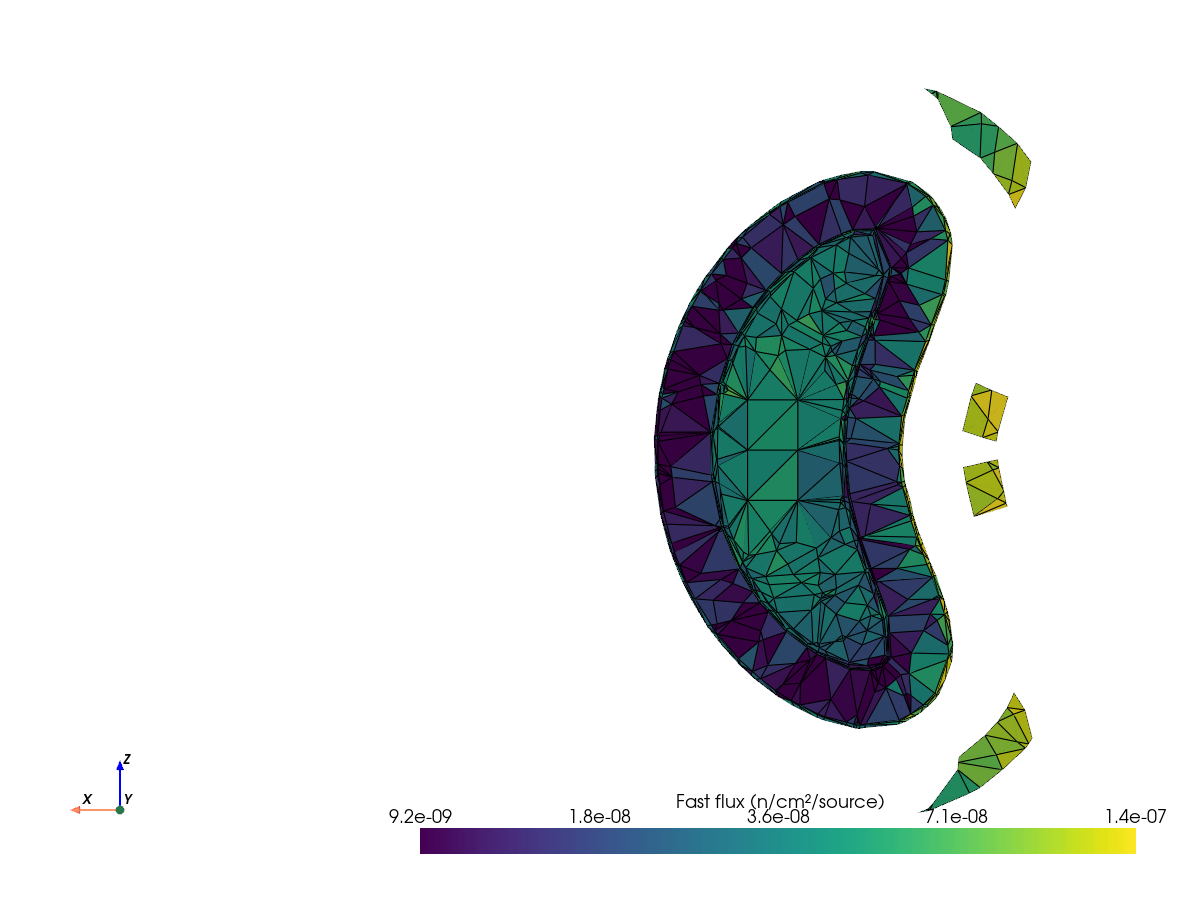

--- Scalar results (per source neutron) ---
  TBR (natural Li FLiBe):  0.0078
  Total coil heating:      2.8986e+05 eV
  First-wall fast flux:    1.1303e+01 n/cm²

Note: TBR < 1 is expected with natural lithium. A real breeding
blanket would use ~30-60% Li-6 enrichment, pushing TBR > 1.


In [10]:
with openmc.StatePoint(statepoint_path) as sp:
    flux_int = sp.get_tally(name="flux_mesh").mean.flatten()

    # Load the tally mesh. The .h5m contains 2D boundary triangles in
    # addition to the 3D tets — extract the tets so cell counts line up
    # with the openmc tally length.
    pv_mesh = pv.read(str(tally_mesh_path))
    pv_tets = pv_mesh.extract_cells_by_type(pv.CellType.TETRA)

    # Convert integrated flux per cell (n·cm / source) to flux density
    # (n / cm² / source) so the colourmap compares flux independently of
    # tet volume. Clamp zero-flux cells to a small floor for log scale.
    pv_tets = pv_tets.compute_cell_sizes(length=False, area=False, volume=True)
    volumes = np.asarray(pv_tets.cell_data["Volume"])
    flux_density = flux_int / np.maximum(volumes, 1e-300)
    nonzero = flux_density[flux_density > 0]
    floor = nonzero.min()
    pv_tets.cell_data["flux"] = np.where(flux_density > 0, flux_density, floor)
    clim = (np.percentile(nonzero, 5), np.percentile(nonzero, 99))

    # Slice the geometry through the y=0 plane to expose two W7-X
    # poloidal cross-sections; camera-zoom onto the +x cross-section so
    # the radial attenuation through firstwall+blanket is legible.
    slice_y = pv_tets.slice(normal="y", origin=(0, 0, 0))

    pl = pv.Plotter(off_screen=True, window_size=(1200, 900))
    pl.add_mesh(
        slice_y,
        scalars="flux",
        cmap="viridis",
        log_scale=True,
        clim=clim,
        show_edges=True,
        edge_color="black",
        line_width=0.3,
        scalar_bar_args={
            "title": "Fast flux (n/cm²/source)",
            "fmt": "%.1e",
        },
    )
    pl.camera_position = [(1700, 5000, 0), (1700, 0, 0), (0, 0, 1)]
    pl.camera.zoom(2.8)
    pl.show_axes()
    screenshot_path = tmpdir / "flux_slice.png"
    pl.screenshot(str(screenshot_path))
    pl.close()
    display(Image(str(screenshot_path), width=900))

    def scalar(name):
        try:
            return float(sp.get_tally(name=name).mean.sum())
        except (LookupError, KeyError):
            return None

    tbr = scalar("tbr")
    coil_heating = scalar("coil_heating")
    fw_flux = scalar("firstwall_flux")

print("--- Scalar results (per source neutron) ---")
print(f"  TBR (natural Li FLiBe):  {tbr:.4f}" if tbr is not None else "  TBR:  n/a")
print(
    f"  Total coil heating:      {coil_heating:.4e} eV"
    if coil_heating is not None
    else "  Coil heating: n/a"
)
print(
    f"  First-wall fast flux:    {fw_flux:.4e} n/cm²"
    if fw_flux is not None
    else "  First-wall flux: n/a"
)
print()
print("Note: TBR < 1 is expected with natural lithium. A real breeding")
print("blanket would use ~30-60% Li-6 enrichment, pushing TBR > 1.")

## Closing

This notebook ran the complete basalt → stellarmesh → OpenMC pipeline against a public W7-X fixture, producing a 3D fast-flux visualization.

See [basalt usage](../../usage.rst), [format reference](../../format.rst), and [stellarmesh tutorials](https://stellarmesh.readthedocs.io/en/latest/tutorials.html) for next steps.
